# 정적분의 계산

$f$가 $[a,b]$에서 연속이면

$$
\int_a^b f(x)\,dx = F(b)-F(a)
$$

($F'=f$). **넷 넓이**(부호 있는 넓이)와 연결된다.

## 1. 정적분의 정의와 계산


In [5]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x')

f = 4*x**2 + 3*x + 2
a, b = 0, 2

F = sp.integrate(f, x)
print("부정적분 F(x) =")
display(F)

I = sp.integrate(f, (x, a, b))
print(f"∫_{a}^{b} f(x) dx = F({b}) − F({a}) =")
display(I)
print("검산:", F.subs(x, b) - F.subs(x, a))


부정적분 F(x) =


∫_0^2 f(x) dx = F(2) − F(0) =


검산: 62/3


**sp.integrate(f, (x, a, b))**: <br>
=> 정적분 $\int_a^b$

**성질**: $\int_a^a=0$, $\int_a^b=-\int_b^a$, 구간 가법성.


In [6]:
print("∫₁¹ =", sp.integrate(f, (x, 1, 1)))
print("∫₂⁰ =", sp.integrate(f, (x, 2, 0)))
print("∫₀¹ + ∫₁² =", sp.integrate(f, (x, 0, 1)) + sp.integrate(f, (x, 1, 2)))


∫₁¹ = 0
∫₂⁰ = -62/3
∫₀¹ + ∫₁² = 62/3


## 시각화: 곡선 아래 넓이 (넷 넓이)

$x$축 위는 $+$ , 아래는 $-$. $\int_{-2}^{2}(x^2-1)\,dx$ 처럼 부호가 갈리면 알넓이와 넷 넓이가 다름

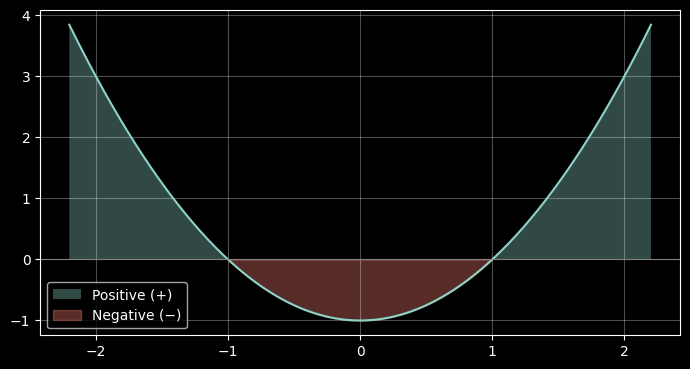

In [12]:
f_area = x**2 - 1
f_n = sp.lambdify(x, f_area, "numpy")
xs = np.linspace(-2.2, 2.2, 400)
ys = f_n(xs)

net = sp.integrate(f_area, (x, -2, 2))
abs_area = sp.integrate(sp.Abs(f_area), (x, -2, 2))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(xs, ys, color="C0")
ax.axhline(0, color="gray", lw=0.8)
ax.fill_between(xs, 0, ys, where=(ys >= 0), alpha=0.35, label="Positive (+)")
ax.fill_between(xs, 0, ys, where=(ys < 0), alpha=0.35, color="C3", label="Negative (−)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 정적분의 치환적분법과 부분적분법

치환할 때 **한계도 $u$로 바꿈**. 부분적분은

$$
\int_a^b u\,dv = \bigl[uv\bigr]_a^b - \int_a^b v\,du
$$


In [8]:
# 치환: ∫₀¹ 2x (x²+1) dx , u = x²+1  → x:0→1 이면 u:1→2
expr = 2*x*(x**2 + 1)
I = sp.integrate(expr, (x, 0, 1))
u = sp.symbols('u')
I_u = sp.integrate(u, (u, 1, 2))
print("직접:")
display(I)
print("u 한계 [1,2]:")
display(I_u)

# 부분적분: ∫₀^π x sin x dx
expr2 = x * sp.sin(x)
print("∫₀^π x sin x dx =")
display(sp.integrate(expr2, (x, 0, sp.pi)))


직접:


u 한계 [1,2]:


∫₀^π x sin x dx =


## 3. 정적분으로 정의된 함수 (FTC)

$$
F(x)=\int_a^x f(t)\,dt \quad\Rightarrow\quad F'(x)=f(x)
$$


In [9]:
t = sp.symbols('t')
f_t = t**2 + 3*t + 2
F = sp.integrate(f_t, (t, 0, x))

print("F(x) = ∫₀ˣ f(t) dt =")
display(F)
print("F'(x) =")
display(sp.diff(F, x))
print("f(x)와 같은가?", sp.diff(F, x) == f_t.subs(t, x))

# 합성: d/dx ∫₀^{x²} sin t dt = sin(x²)·2x
G = sp.integrate(sp.sin(t), (t, 0, x**2))
print("d/dx ∫₀^{x²} sin t dt =")
display(sp.diff(G, x))
display(sp.simplify(sp.diff(G, x) - sp.sin(x**2)*2*x))


F(x) = ∫₀ˣ f(t) dt =


F'(x) =


f(x)와 같은가? True
d/dx ∫₀^{x²} sin t dt =


**연쇄법칙**: $F(x)=\int_a^{u(x)} f(t)\,dt$ 이면 $F'(x)=f(u(x))u'(x)$.


## 시각화: $F(x)=\int_0^x f$ 는 누적 넓이

왼쪽 색칠 영역이 오른쪽 $F(x)$의 함숫값

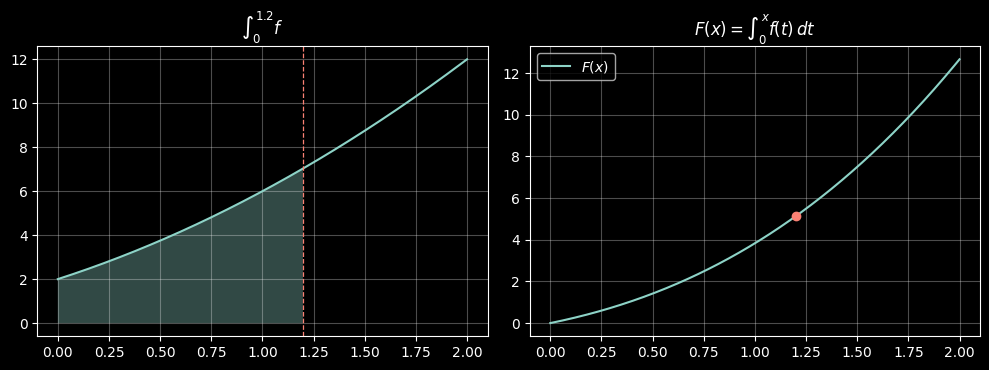

In [13]:
f_plot = x**2 + 3*x + 2
F_plot = sp.integrate(f_plot, (x, 0, x))
fn = sp.lambdify(x, f_plot, "numpy")
Fn = sp.lambdify(x, F_plot, "numpy")

xs = np.linspace(0, 2, 400)
x0 = 1.2
mask = xs <= x0

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(xs, fn(xs))
axes[0].fill_between(xs[mask], 0, fn(xs[mask]), alpha=0.35)
axes[0].axvline(x0, color="C3", ls="--", lw=0.9)
axes[0].set_title(rf"$\int_0^{{{x0}}} f$")
axes[0].grid(True, alpha=0.3)

axes[1].plot(xs, Fn(xs), label=r"$F(x)$")
axes[1].scatter([x0], [float(Fn(x0))], zorder=5, color="C3")
axes[1].set_title(r"$F(x)=\int_0^x f(t)\,dt$")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()